In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

conn = sqlite3.connect("../data/nifty100.db")

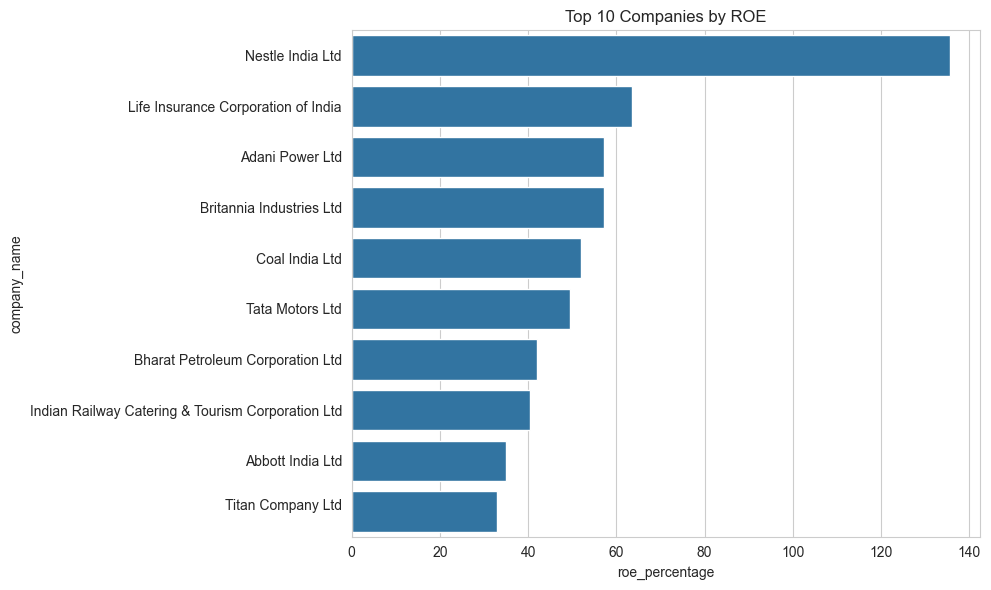

In [2]:
query = """
SELECT company_name, roe_percentage
FROM companies
ORDER BY roe_percentage DESC
LIMIT 10
"""

df = pd.read_sql(query, conn)

plt.figure(figsize=(10,6))
sns.barplot(data=df, x="roe_percentage", y="company_name")
plt.title("Top 10 Companies by ROE")
plt.tight_layout()
plt.savefig("../charts/top10_roe.png")
plt.show()

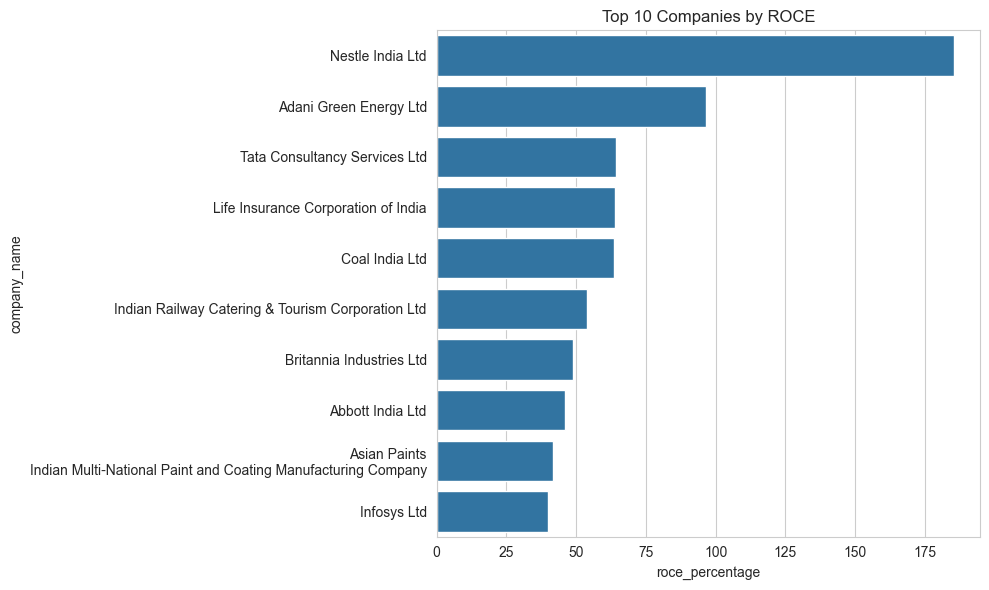

In [3]:
query = """
SELECT company_name, roce_percentage
FROM companies
ORDER BY roce_percentage DESC
LIMIT 10
"""

df = pd.read_sql(query, conn)

plt.figure(figsize=(10,6))
sns.barplot(data=df, x="roce_percentage", y="company_name")
plt.title("Top 10 Companies by ROCE")
plt.tight_layout()
plt.savefig("../charts/top10_roce.png")
plt.show()

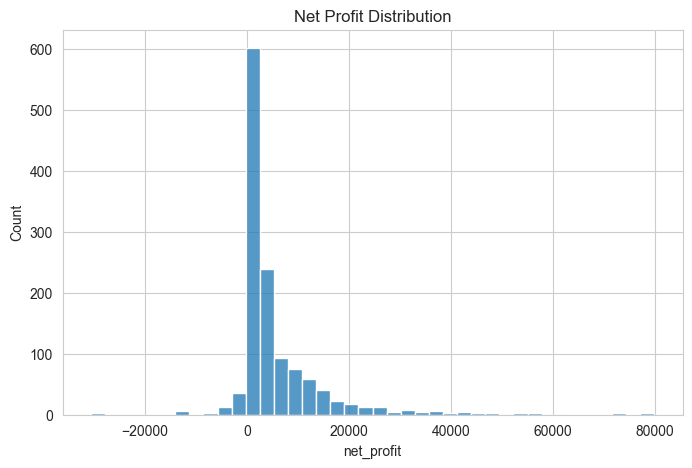

In [4]:
df = pd.read_sql(
"""
SELECT net_profit
FROM profit_loss
""",
conn
)

plt.figure(figsize=(8,5))
sns.histplot(df["net_profit"], bins=40)
plt.title("Net Profit Distribution")
plt.savefig("../charts/net_profit_distribution.png")
plt.show()

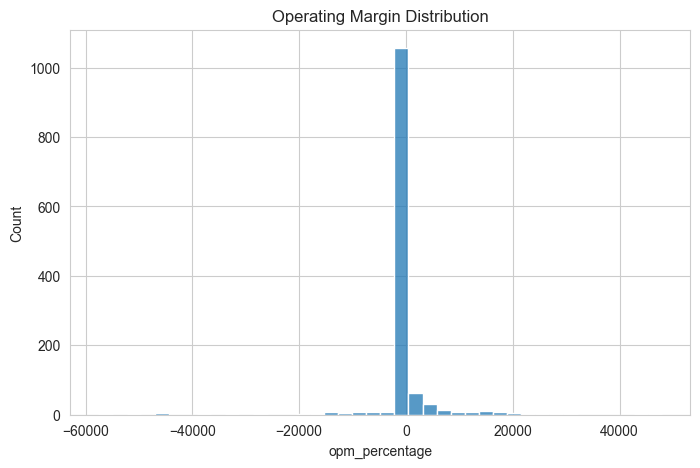

In [5]:
df = pd.read_sql(
"""
SELECT opm_percentage
FROM profit_loss
""",
conn
)

plt.figure(figsize=(8,5))
sns.histplot(df["opm_percentage"], bins=40)
plt.title("Operating Margin Distribution")
plt.savefig("../charts/opm_distribution.png")
plt.show()

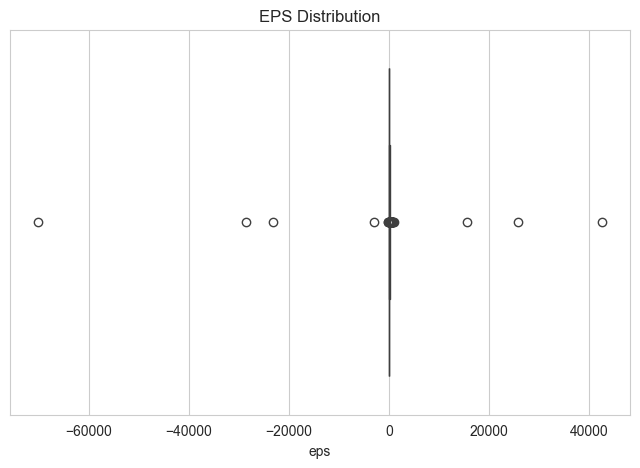

In [6]:
df = pd.read_sql(
"""
SELECT eps
FROM profit_loss
""",
conn
)

plt.figure(figsize=(8,5))
sns.boxplot(x=df["eps"])
plt.title("EPS Distribution")
plt.savefig("../charts/eps_distribution.png")
plt.show()

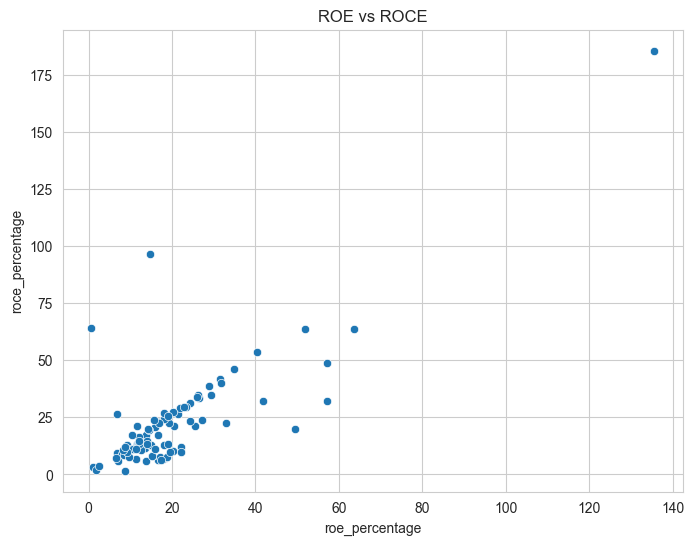

In [7]:
df = pd.read_sql(
"""
SELECT roe_percentage, roce_percentage
FROM companies
""",
conn
)

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="roe_percentage",
    y="roce_percentage"
)
plt.title("ROE vs ROCE")
plt.savefig("../charts/roe_vs_roce.png")
plt.show()

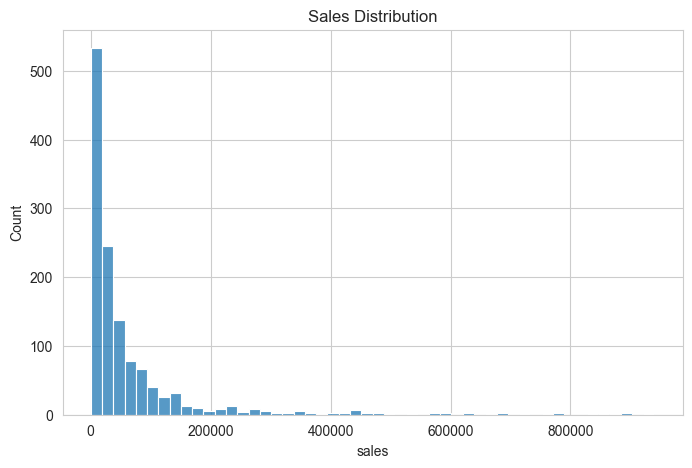

In [8]:
df = pd.read_sql(
"""
SELECT sales
FROM profit_loss
""",
conn
)

plt.figure(figsize=(8,5))
sns.histplot(df["sales"], bins=50)
plt.title("Sales Distribution")
plt.savefig("../charts/sales_distribution.png")
plt.show()

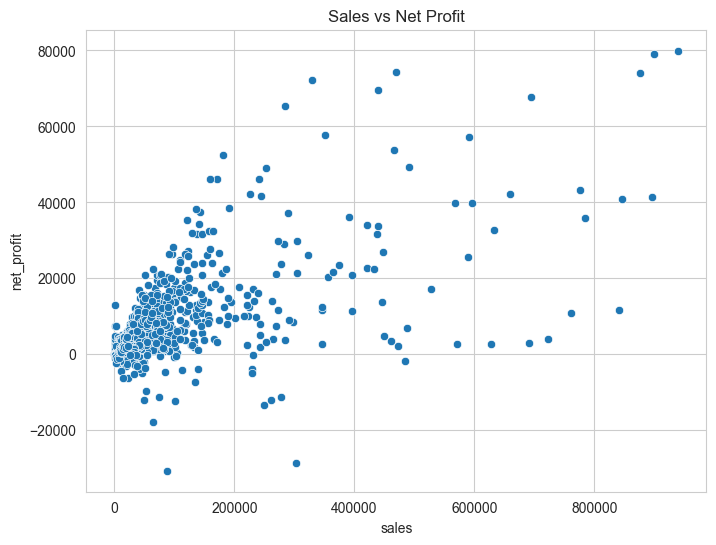

In [9]:
df = pd.read_sql(
"""
SELECT sales, net_profit
FROM profit_loss
""",
conn
)

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="sales",
    y="net_profit"
)
plt.title("Sales vs Net Profit")
plt.savefig("../charts/sales_vs_profit.png")
plt.show()

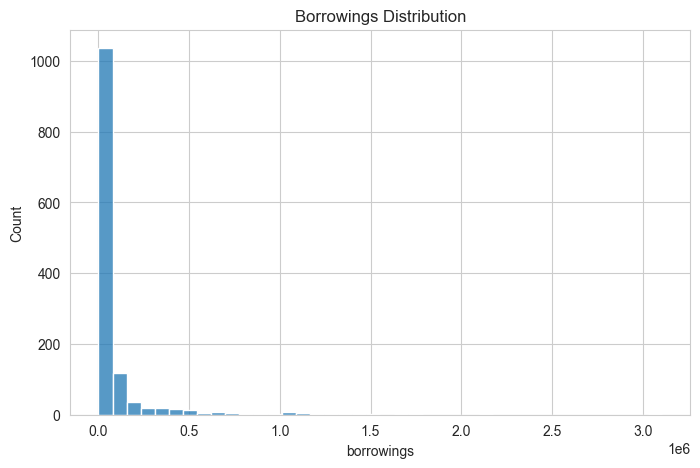

In [10]:
df = pd.read_sql(
"""
SELECT borrowings
FROM balance_sheet
""",
conn
)

plt.figure(figsize=(8,5))
sns.histplot(df["borrowings"], bins=40)
plt.title("Borrowings Distribution")
plt.savefig("../charts/borrowings_distribution.png")
plt.show()

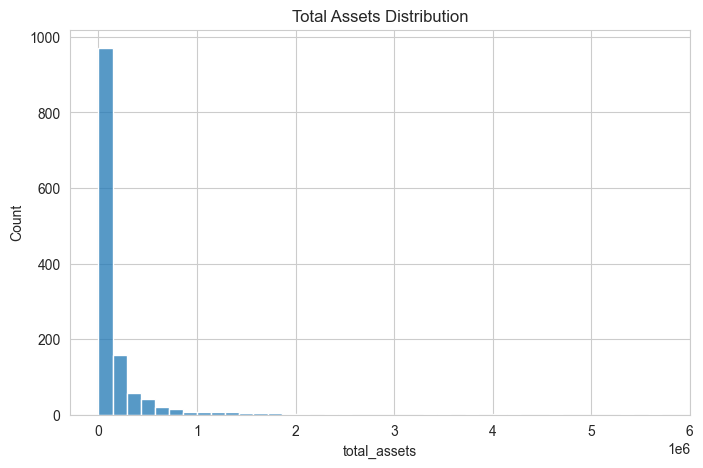

In [11]:
df = pd.read_sql(
"""
SELECT total_assets
FROM balance_sheet
""",
conn
)

plt.figure(figsize=(8,5))
sns.histplot(df["total_assets"], bins=40)
plt.title("Total Assets Distribution")
plt.savefig("../charts/assets_distribution.png")
plt.show()

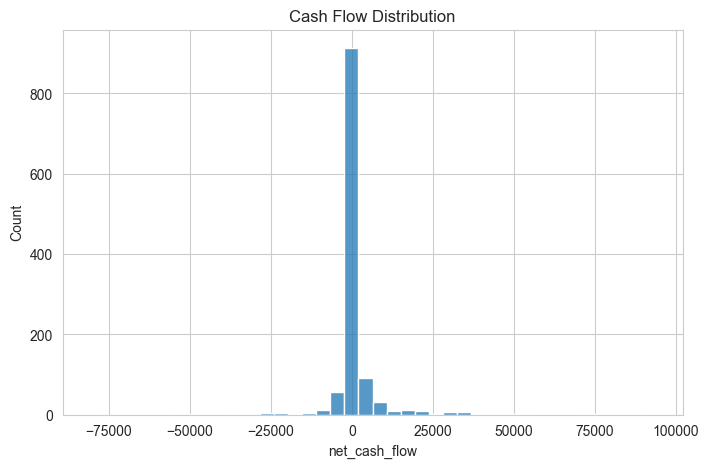

In [12]:
df = pd.read_sql(
"""
SELECT net_cash_flow
FROM cashflow
""",
conn
)

plt.figure(figsize=(8,5))
sns.histplot(df["net_cash_flow"], bins=40)
plt.title("Cash Flow Distribution")
plt.savefig("../charts/cashflow_distribution.png")
plt.show()

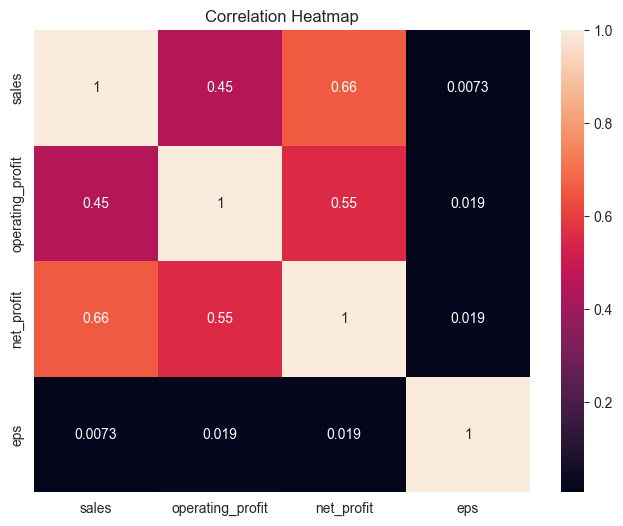

In [13]:
df = pd.read_sql(
"""
SELECT sales,
operating_profit,
net_profit,
eps
FROM profit_loss
""",
conn
)

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.savefig("../charts/correlation_heatmap.png")
plt.show()

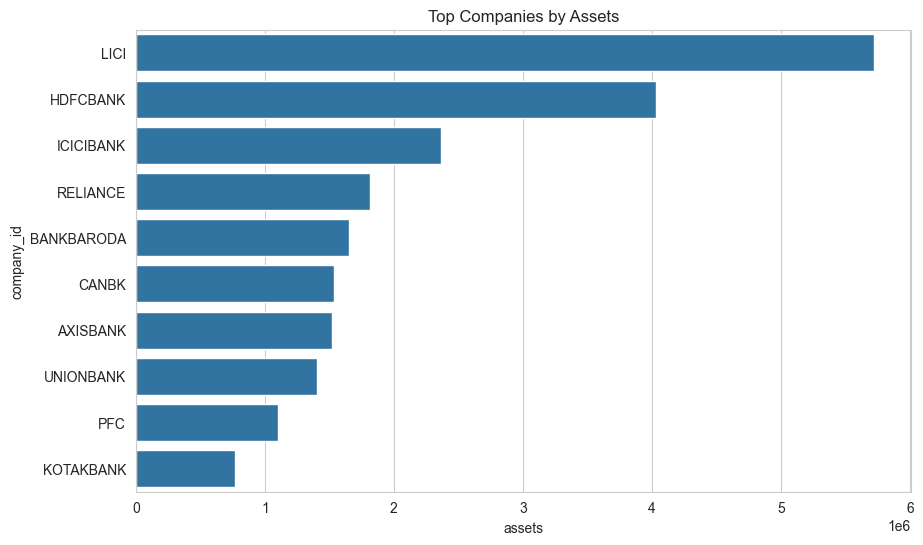

In [14]:
query = """
SELECT company_id,
MAX(total_assets) AS assets
FROM balance_sheet
GROUP BY company_id
ORDER BY assets DESC
LIMIT 10
"""

df = pd.read_sql(query, conn)

plt.figure(figsize=(10,6))
sns.barplot(
    data=df,
    x="assets",
    y="company_id"
)
plt.title("Top Companies by Assets")
plt.savefig("../charts/top_assets.png")
plt.show()

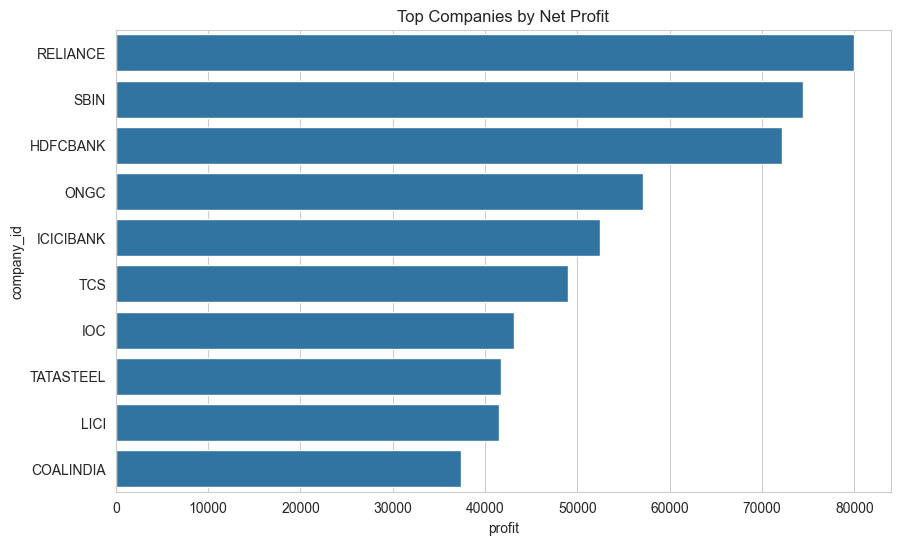

In [15]:
query = """
SELECT company_id,
MAX(net_profit) AS profit
FROM profit_loss
GROUP BY company_id
ORDER BY profit DESC
LIMIT 10
"""

df = pd.read_sql(query, conn)

plt.figure(figsize=(10,6))
sns.barplot(
    data=df,
    x="profit",
    y="company_id"
)
plt.title("Top Companies by Net Profit")
plt.savefig("../charts/top_profit.png")
plt.show()

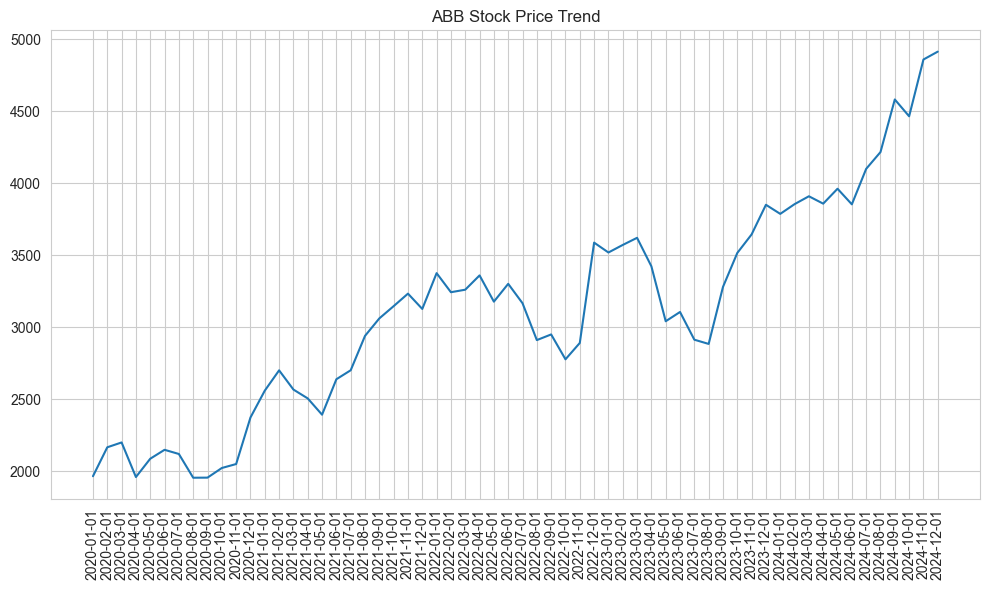

In [16]:
df = pd.read_sql(
"""
SELECT date, close_price
FROM stock_prices
WHERE company_id='ABB'
""",
conn
)

plt.figure(figsize=(10,6))
plt.plot(df["date"], df["close_price"])
plt.xticks(rotation=90)
plt.title("ABB Stock Price Trend")
plt.tight_layout()
plt.savefig("../charts/abb_price_trend.png")
plt.show()